In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Load pre-processed data
- Logistic Regression
- Decision Tree (CART)
- Random Forest
- KNN
- SVM

In [19]:
model_cfgs = {
    "LR": {
        "csv_path": "dataset/processed_logistic_regression.csv",
        "clf": LogisticRegression(random_state=0) # fix random state
    },
    "DT": {
        "csv_path": "dataset/processed_decision_tree.csv",
        "clf": DecisionTreeClassifier(random_state=0, max_depth=3) # depth 3 has best test acc
    },
    "RF":{
        "csv_path": "dataset/processed_random_forest.csv",
        "clf": RandomForestClassifier(max_depth=2, random_state=0) # depth 2 has best test acc
    },
    "KNN":{
        "csv_path": "dataset/processed_knn.csv",
        "clf": KNeighborsClassifier()
    },
    "SVM":{
        "csv_path": "dataset/processed_svm.csv",
        "clf": SVC(probability=True, random_state=0) 
    }
}

## Train 5 classifier
- 5-fold CV
- Train
- test + collect ROC / Confusion Matrix data

In [20]:
test_result = {}

print("================== Start training ===================")
for name, config in model_cfgs.items():
    # Read cvs
    df = None
    try:
        df = pd.read_csv(config['csv_path'])
        # display(df)
    except FileNotFoundError:
        print(f"{config['csv_path']} Not exist")
    x = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # 5-Fold cross validation
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_results = cross_validate(config["clf"], x, y, cv=5, scoring=scoring)

    # Split train/test data set, 0.8/0.2
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=0)

    # Train
    clf = config["clf"]
    clf.fit(x_train, y_train)

    # Test
    y_pred = clf.predict(x_test)
    y_probs = clf.predict_proba(x_test)[:, 1]

    test_result[name] = {
        "model": clf,
        "X_test": x_test,
        "y_test": y_test,
        "y_probs": y_probs,
        "cv_scores": cv_results, # 儲存 CV 的詳細結果
        "metrics": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_probs)
        }
    }
    print(f"{name} finish training")
    print(f"   Train Accuracy: {clf.score(x_train, y_train):.4f} | Test Accuracy: {clf.score(x_test, y_test):.4f}")
    print("-" * 50)


================== Start training ===================
LR finish training
   Train Accuracy: 0.8760 | Test Accuracy: 0.8197
--------------------------------------------------
DT finish training
   Train Accuracy: 0.8554 | Test Accuracy: 0.7869
--------------------------------------------------
RF finish training
   Train Accuracy: 0.8719 | Test Accuracy: 0.8197
--------------------------------------------------
KNN finish training
   Train Accuracy: 0.9091 | Test Accuracy: 0.7705
--------------------------------------------------
SVM finish training
   Train Accuracy: 0.9256 | Test Accuracy: 0.7705
--------------------------------------------------


## Plot Test Result
- Basic metrics
    - Acc
    - Precision
    - Recall
    - f1
    - AUC
- ROC curve
- Confusion Matrix
- 5-fold CV

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
!mkdir ./img

mkdir: cannot create directory ‘./img’: File exists


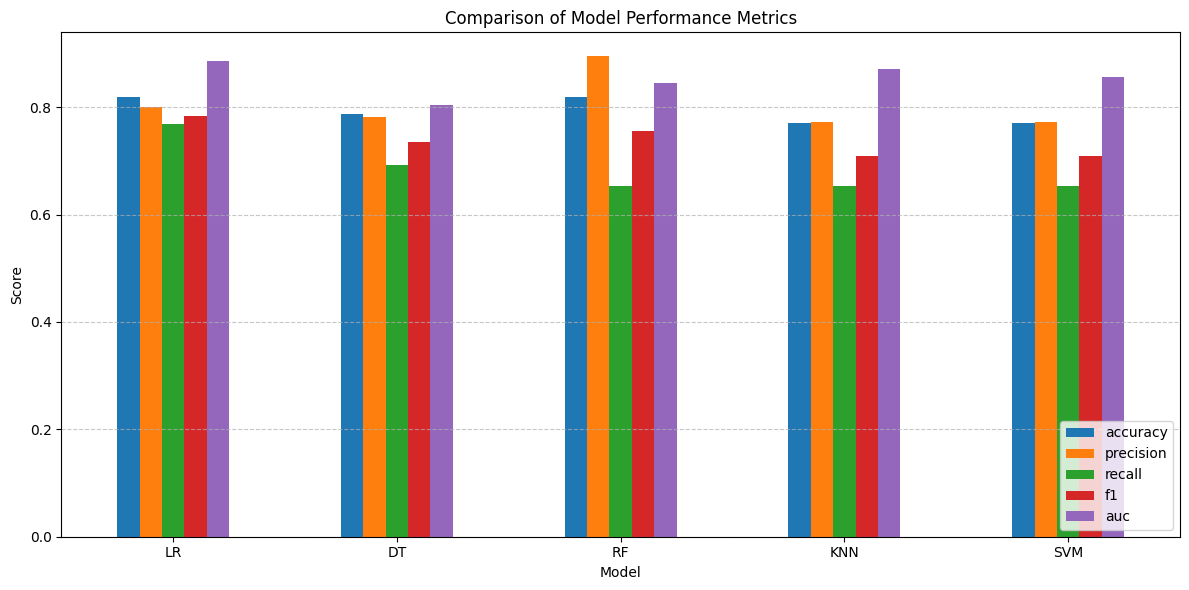

<Figure size 640x480 with 0 Axes>

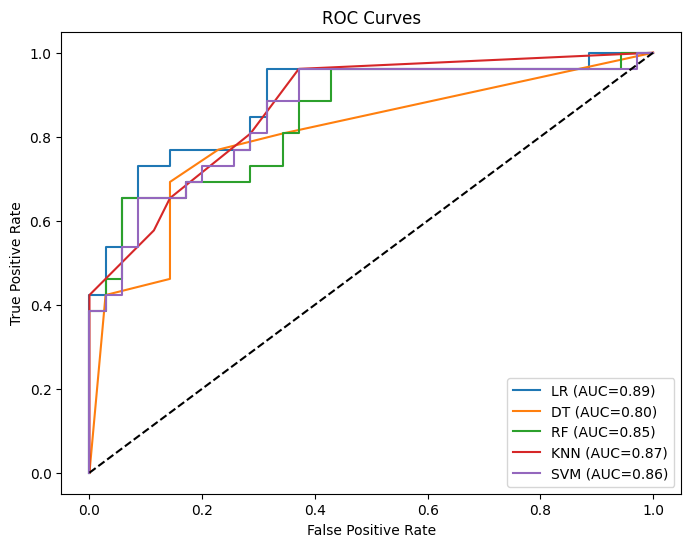

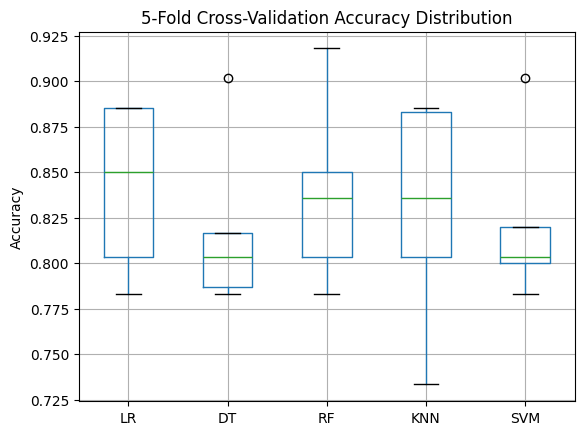

<Figure size 640x480 with 0 Axes>

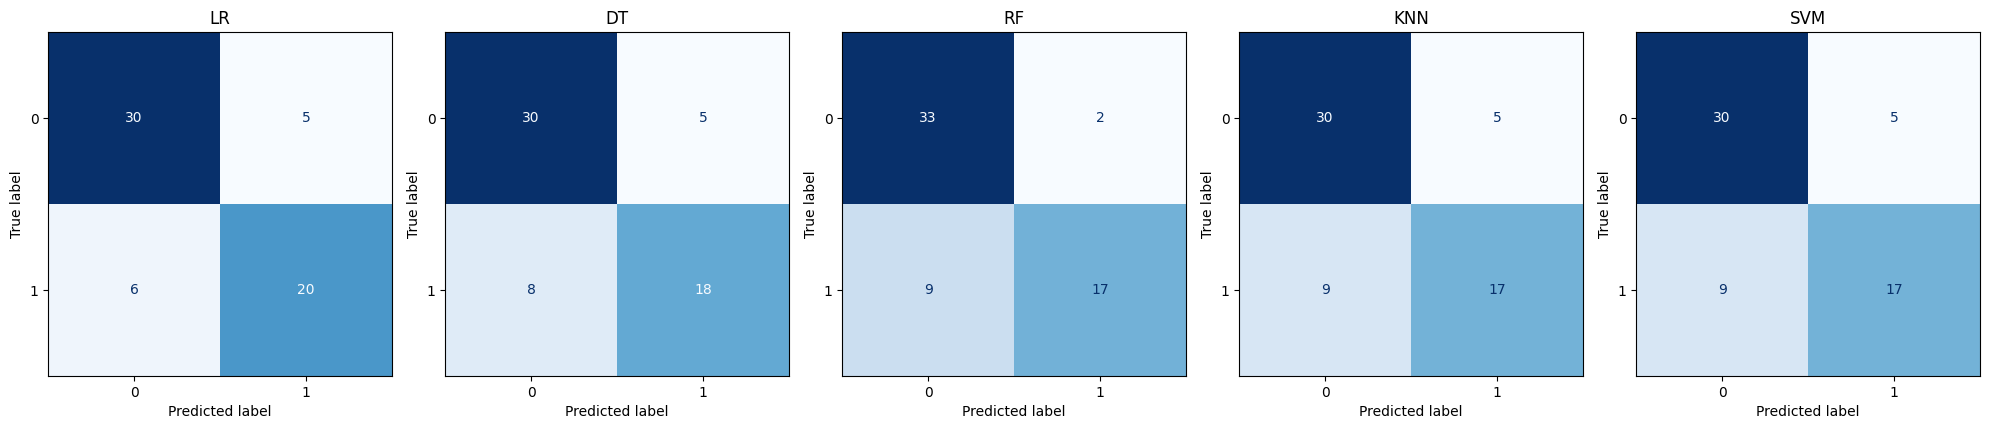

<Figure size 640x480 with 0 Axes>

In [22]:
def plot_project_visualizations(test_result):
    # 1. 準備綜合比較表格 (Metrics Comparison)
    metrics_list = []
    for name, data in test_result.items():
        row = data["metrics"].copy()
        row["Model"] = name
        metrics_list.append(row)
    df_metrics = pd.DataFrame(metrics_list).set_index("Model")

    # A. 繪製：各模型指標比較圖 (Bar Chart)
    df_metrics.plot(kind='bar', figsize=(12, 6), rot=0)
    plt.title("Comparison of Model Performance Metrics")
    plt.ylabel("Score")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    file_name = "./img/metrics.png"
    plt.savefig(file_name, dpi=300)


    # B. 繪製：合併 ROC 曲線圖
    plt.figure(figsize=(8, 6))
    for name, data in test_result.items():
        fpr, tpr, _ = roc_curve(data["y_test"], data["y_probs"])
        plt.plot(fpr, tpr, label=f"{name} (AUC={data['metrics']['auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()
    file_name = "./img/ROC.png"
    plt.savefig(file_name, dpi=300)

    # C. 繪製：5-Fold CV 盒鬚圖 (Box Plot) - 展現模型的穩定性
    cv_data = {name: data["cv_scores"]["test_accuracy"] for name, data in test_result.items()}
    pd.DataFrame(cv_data).boxplot(figsize=(10, 5))
    plt.title("5-Fold Cross-Validation Accuracy Distribution")
    plt.ylabel("Accuracy")
    plt.show()
    file_name = "./img/5_fold_CV.png"
    plt.savefig(file_name, dpi=300)

    # D. 繪製：混淆矩陣 (Confusion Matrices - 這裡我們用子圖畫成一排)
    fig, axes = plt.subplots(1, len(test_result), figsize=(20, 4))
    for i, (name, data) in enumerate(test_result.items()):
        ConfusionMatrixDisplay.from_estimator(
            data["model"], data["X_test"], data["y_test"], 
            ax=axes[i], cmap="Blues", colorbar=False
        )
        axes[i].set_title(name)
    plt.tight_layout()
    plt.show()
    file_name = "./img/confusion.png"
    plt.savefig(file_name, dpi=300)

plot_project_visualizations(test_result)